# Análisis de un test A/B para una tienda online

#### Objetivo del proyecto: Priorizar las hipótesis que pueden ayudar a aumentar los ingresos de ls tienda onlina, lanzar un test A/B y analizar los resultados

## Parte 1. Análisis exploratorio de datos

In [3]:
# Cargamos las librerías que necesitaremos:
import pandas as pd
from scipy import stats as st
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# Vemos las primeras 10 filas del data set:
print("Primeras filas de hypotheses:")
hypotheses.head(10)


Primeras filas de hypotheses:


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


In [ ]:
# Llamamos al método info() para ver el tipo de datos de cada columna:
print(hypotheses.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes
None


In [ ]:
# Vemos solo las filas de la columna 'Hypothesis' para estudiarlas antes de priorizarlas:
for row in hypotheses['Hypothesis']:
    print(row)

Add two new channels for attracting traffic. This will bring 30% more users
Launch your own delivery service. This will shorten delivery time
Add product recommendation blocks to the store's site. This will increase conversion and average purchase size
Change the category structure. This will increase conversion since users will find the products they want more quickly
Change the background color on the main page. This will increase user engagement
Add a customer review page. This will increase the number of orders
Show banners with current offers and sales on the main page. This will boost conversion
Add a subscription form to all the main pages. This will help you compile a mailing list
Launch a promotion that gives users discounts on their birthdays


In [ ]:
# Cargamos los data sets orders y visits:
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

In [ ]:
# Vemos las primeras 10 filas de orders:
print("Primeras filas de orders:")
orders.head(10)

Primeras filas de orders:


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B
6,398296753,2900797465,2019-08-15,30.6,B
7,2626614568,78758296,2019-08-15,20.1,A
8,1576988021,295230930,2019-08-15,215.9,A
9,1506739906,1882260405,2019-08-15,30.5,B


In [ ]:
# Llamamos al método info() para ver el tipo de datos de cada columna:
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
None


In [ ]:
# Cambiamos los datos de la columna 'date' a tipo fecha:
orders['date'] = pd.to_datetime(orders['date'])

In [ ]:
# Comprobamos que no haya filas duplicadas:
print(orders.duplicated().sum())

0


In [ ]:
# Comprobamos que no haya visitantes que estén en ambos grupos. Extraemos los visitantes únicos del grupo A y el B:
visitors_A = set(orders[orders['group'] == 'A']['visitorId'].unique())
visitors_B = set(orders[orders['group'] == 'B']['visitorId'].unique())

In [ ]:
# Obtenemos los visitantes que están en ambos grupos con el método intersection:
duplicated_visitors = visitors_A.intersection(visitors_B)
print(f"Número de visitantes en ambos grupos: {len(duplicated_visitors)}")
print(f"Visitantes duplicados: {duplicated_visitors}")

Número de visitantes en ambos grupos: 58
Visitantes duplicados: {3957174400, 3984495233, 2780786433, 1294878855, 1648269707, 1614305549, 4120364173, 232979603, 199603092, 4266935830, 2712142231, 2587333274, 2716752286, 3891541246, 1668030113, 2654030115, 3234906277, 1230306981, 1404934699, 3803269165, 2949041841, 237748145, 457167155, 2927087541, 1738359350, 3062433592, 3656415546, 818047933, 393266494, 963407295, 471551937, 2579882178, 3202540741, 2686716486, 1333886533, 2044997962, 3941795274, 1801183820, 2378935119, 4256040402, 4069496402, 3766097110, 8300375, 351125977, 1602967004, 276558944, 2038680547, 3951559397, 3963646447, 4186807279, 3717692402, 1959144690, 2458001652, 2600415354, 2954449915, 1316129916, 477780734, 3972127743}


In [ ]:
# Eliminamos estos visitantes:
orders_clean = orders[~orders['visitorId'].isin(duplicated_visitors)]
# Comprobamos que se hayan eliminado:
print(orders_clean[orders_clean['visitorId'].isin(duplicated_visitors)])

Empty DataFrame
Columns: [transactionId, visitorId, date, revenue, group]
Index: []


Decidí eliminar los visitantes duplicados ya que no hay forma de saber a qué grupo pertenecen. Si los dejamos, podríamos llegar a conclusiones incorrectas.

In [ ]:
# Vemos las primeras 10 filas de visits:
print("Primeras filas de visits:")
visits.head(10)

Primeras filas de visits:


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


In [ ]:
# Llamamos al método info() para ver el tipo de datos de cada columna:
print(visits.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
None


In [ ]:
# Cambiamos los datos de la columna 'date' a tipo fecha:
visits['date'] = pd.to_datetime(visits['date'])

In [ ]:
# Comprobamos que no haya filas duplicadas:
print(visits.duplicated().sum())

0


In [ ]:
# Comprobamos que no haya filas duplicadas por fecha y grupo:
print(visits[['date', 'group']].duplicated().sum())

0


## Parte 2. Priorización de hipótesis

### 2.1 Framework RICE

In [ ]:
# Creamos la columna 'ICE' para almacenar los resultados, y los mostramos en orden descendente de prioridad:
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']
ice_ordered = hypotheses.sort_values(by ='ICE', ascending = False)
print(ice_ordered[['Hypothesis', 'ICE']])

                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


### 2.1 Framework ICE

In [ ]:
# Creamos la columna 'RICE' para almacenar los resultados, y los mostramos en orden descendente de prioridad:
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']
rice_ordered = hypotheses.sort_values(by ='RICE', ascending = False)
print(rice_ordered[['Hypothesis', 'RICE']])

                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


In [ ]:
# Mostramos la priorización de hipótesis tanto en RICE como en ICE:
print(ice_ordered[['Hypothesis', 'ICE']])
print(rice_ordered[['Hypothesis', 'RICE']])

                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000
                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2


Vemos que la hipótesis número 8 está en el primer lugar en ICE, pues obtuvo un valor de 16.20. Sin embargo, en RICE bajó hasta el quinto lugar, con 16.2. Esto se debe a que tiene un impacto y confianza de 9 y un esfuerzo de 5. Sin embargo, solo tiene alcance de 1 usuario. En mi opinión, quedarnos con esta hipótesis no sería lo mejor, pues aunque tiene un impacto y una confianza altos, y requiere un esfuerzo medio, tan solo alcanza un usuario. No creo que valga la pena hacer este cambio si solo afectará a un usuario. 

En el segundo lugar en ICE se encuentra la hipótesis 0, con 13.33, pues su impacto y confianza son 10 y 8 respectivamente, pero el esfuerzo es de 6. Dado que su alcance fue de solo 3 usuarios, bajó al tercer puesto en RICE con 40. Personalmente, tampoco me quedaría con esta hipótesis, pues un alcance de 3 usuarios sigue siendo bajo y requiere un poco más de esfuerzo que la número 8.

El tercer lugar de ICE lo ocupa la hipótesis 7 con 11.20. Su impacto es de 7, su confianza es de 8 y su esfuerzo es de 5. En RICE, se encuentra en el primer puesto, ya que su alcance es de 10 usuarios, el más alto. Opino que esta hipótesis es la opción más conveniente, pues su impacto y confianza son relativamente altos, implica un esfuerzo medio y alcanza a la mayor cantidad de usuarios. 

## Parte 3. Análisis del test A/B

### 3.1 Ingreso acumulado por grupo

In [ ]:
# Sumamos los ingresos por día y grupo:
daily_revenue = orders_clean.groupby(['group', 'date'], as_index=False)['revenue'].sum()

# 2) Ordenamos cronológicamente dentro de cada grupo
daily_revenue = daily_revenue.sort_values(['group', 'date'])

# 3) Realizamos el cálculo del ingreso acumulado por grupo con el método 'cumsum():
daily_revenue['cumulative_revenue'] = daily_revenue.groupby('group')['revenue'].cumsum()

# Resultado final
cumulative_revenue = daily_revenue
cumulative_revenue.head()

,group,date,revenue,cumulative_revenue
0,A,2019-08-01,2266.6,2266.6
1,A,2019-08-02,1468.3,3734.9
2,A,2019-08-03,1815.2,5550.1
3,A,2019-08-04,675.5,6225.6
4,A,2019-08-05,1398.0,7623.6


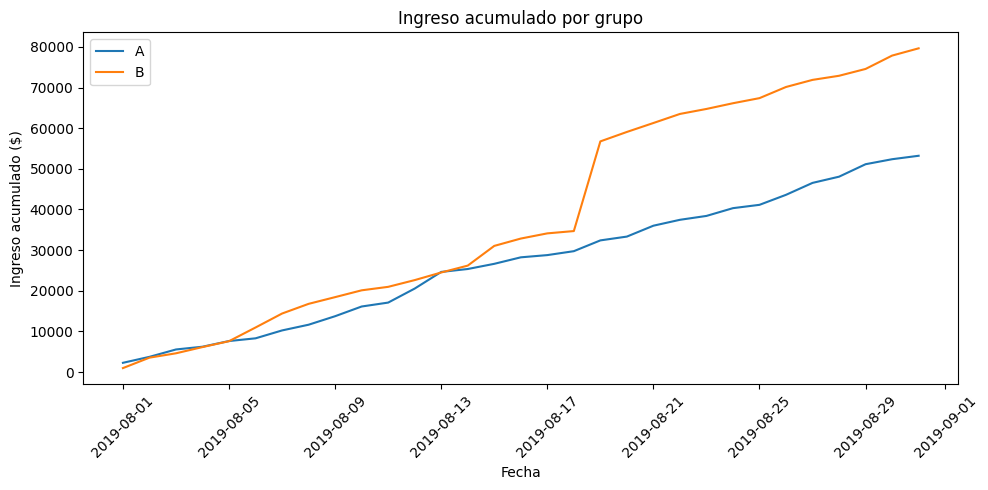

In [ ]:
# DataFrame con ingresos acumulados por día, grupo A
cumulative_revenue_a = cumulative_revenue[cumulative_revenue['group']=='A'][['date','cumulative_revenue']]
# DataFrame con ingresos acumulados por día, grupo B
cumulative_revenue_b = cumulative_revenue[cumulative_revenue['group']=='B'][['date','cumulative_revenue']]

# Trazar el gráfico de ingresos del grupo A
plt.figure(figsize=(10,5))
plt.plot(cumulative_revenue_a['date'], cumulative_revenue_a['cumulative_revenue'], label='A')

# Trazar el gráfico de ingresos del grupo B
plt.plot(cumulative_revenue_b['date'], cumulative_revenue_b['cumulative_revenue'], label='B',)
plt.title('Ingreso acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Vemos que en ambos grupos los ingresos acumulados aumentaron a lo largo del tiempo. Al inicio de la prueba, los ingresos de ambos grupos eran muy similares. Sin embargo, a partir del 8/5, el grupo B empezó a tener más ingresos que el grupo A. Es importante mencionar que esta diferencia fue más notoria a partir del 8/19 aproximadamente hasta el final de la prueba. De hecho, parece que los ingresos tenderán a subir.

### 3.2 Tamaño de pedido promedio acumulado por grupo

In [ ]:
# Ordenamos cronológicamente el data set orders:
orders_sorted = orders_clean.sort_values(['group', 'date'])
# Realizamos el cálculo del tamaño de compra promedio acumulado por grupo con el método 'expanding():
orders_sorted['cumulative_purchase_mean'] = orders_sorted.groupby('group')['revenue'].expanding().mean().reset_index(0, drop=True)
# Resultado final
cumulative_purchase = orders_sorted
# Tomamos el último valor de cada día con el método tail:
daily_avg = cumulative_purchase.groupby(['group', 'date']).tail(1)
daily_avg.head()

,transactionId,visitorId,date,revenue,group,cumulative_purchase_mean
171,2153842875,876081193,2019-08-01,55.4,A,98.547826
289,1651482177,2147998719,2019-08-02,35.0,A,88.926190
471,798048333,3462462738,2019-08-03,40.3,A,84.092424
660,1381001911,907970812,2019-08-04,35.2,A,80.851948
909,1062393,2661240577,2019-08-05,100.8,A,77.006061


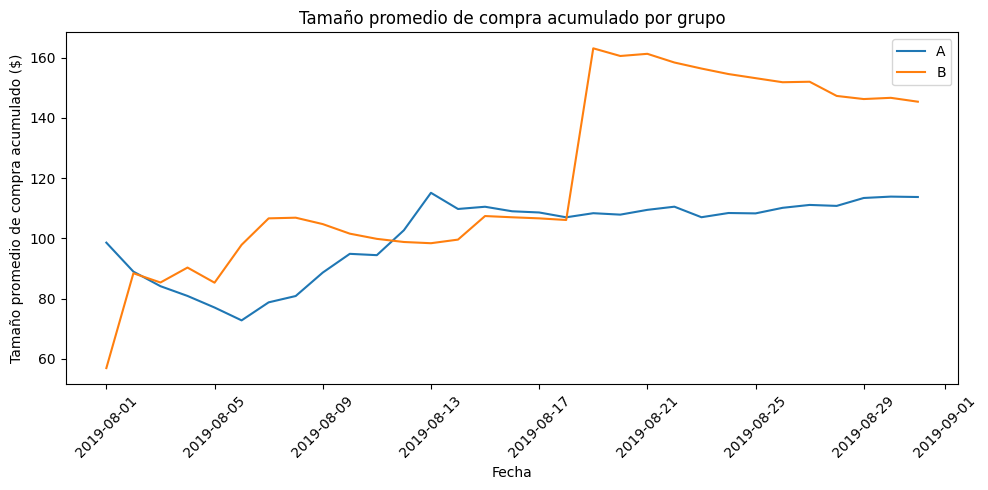

In [ ]:
# Hacemos el gráfico:
# DataFrame con tamaño de compra promedio acumulada por día, grupo A
cumulative_purchase_a = daily_avg[daily_avg['group']=='A'][['date','cumulative_purchase_mean']]

# DataFrame con ingresos acumulados por día, grupo B
cumulative_purchase_b = daily_avg[daily_avg['group']=='B'][['date','cumulative_purchase_mean']]

# Trazar el gráfico de ingresos del grupo A
plt.figure(figsize=(10,5))
plt.plot(cumulative_purchase_a['date'], cumulative_purchase_a['cumulative_purchase_mean'], label='A')

# Trazar el gráfico de ingresos del grupo B
plt.plot(cumulative_purchase_b['date'], cumulative_purchase_b['cumulative_purchase_mean'], label='B')
plt.title('Tamaño promedio de compra acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tamaño promedio de compra acumulado ($)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


En este gráfico, podemos observar más fluctuaciones en ambos grupos. También observamos más picos. Seguramente se deba a pedidos caros que aumentaron el tamaño promedio de compra acumulado. 

En general, el grupo B tuvo un tamaño promedio de compra mayor durante más tiempo que el A. De nuevo, en los últimos días de la prueba el grupo B llevó la delantera, y parece que se está estabilizando. 

### 3.3 Diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A

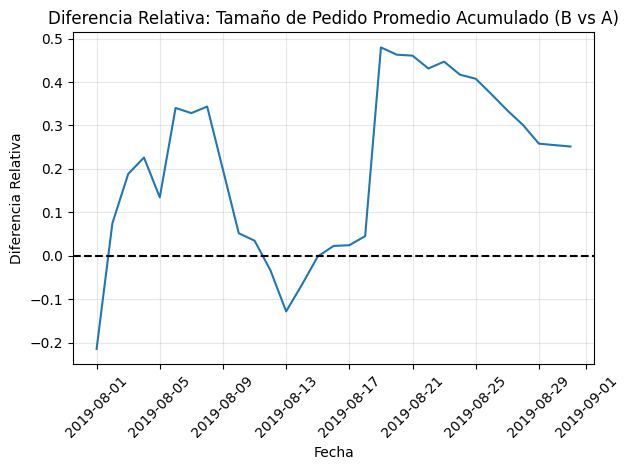

In [ ]:
# Reunimos los datos en un DataFrame
merged_cumulative_purchase = cumulative_purchase_a.merge(cumulative_purchase_b, left_on='date', right_on='date', how='left', suffixes=['A', 'B'])
# Trazarmos un gráfico de diferencia relativa para los tamaños de compra promedio:
plt.plot(merged_cumulative_purchase['date'], (merged_cumulative_purchase['cumulative_purchase_meanB'] / merged_cumulative_purchase['cumulative_purchase_meanA'])  -1)
plt.xticks(rotation=45)
plt.title('Diferencia Relativa: Tamaño de Pedido Promedio Acumulado (B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia Relativa')
plt.grid(True, alpha=0.3)
# agregar el eje X
plt.axhline(y=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()


Veo una gran fluctuación al principio de la prueba. El grupo B comenzó teniendo un tamaño de compra promedio un 20% menor que el A. Fue subiendo y logró superar al A por un 35% aproximadamente. Después volvió a bajar y luego a subir hasta alcanzar un tamaño de compra un 45% más grande que el B. En los últimos días de la prueba fue disminuyendo, pero al final se estabilizó siendo un 25% mayor que el A.

### 3.4 Tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día

In [ ]:
# Calculamos el número de pedidos por día y grupo:
daily_orders = orders_clean.groupby(['group', 'date'], as_index=False).agg({'transactionId':'nunique'})
daily_orders.rename(columns={'transactionId':'orders'}, inplace=True)
daily_orders.head(5)

,group,date,orders
0,A,2019-08-01,23
1,A,2019-08-02,19
2,A,2019-08-03,24
3,A,2019-08-04,11
4,A,2019-08-05,22


In [ ]:
# Unimos con visits
daily_orders_merged = pd.merge(visits, daily_orders, on=['group','date'], how='left')
daily_orders_merged.head(5)

,date,group,visits,orders
0,2019-08-01,A,719,23
1,2019-08-02,A,619,19
2,2019-08-03,A,507,24
3,2019-08-04,A,717,11
4,2019-08-05,A,756,22


In [ ]:
# Calculamos la conversión diaria por grupo diviendo el número de pedidos entre las visitas:
daily_orders_merged['conversion'] = daily_orders_merged['orders'] / daily_orders_merged['visits']
daily_orders_merged.head(5)

,date,group,visits,orders,conversion
0,2019-08-01,A,719,23,0.031989
1,2019-08-02,A,619,19,0.030695
2,2019-08-03,A,507,24,0.047337
3,2019-08-04,A,717,11,0.015342
4,2019-08-05,A,756,22,0.029101


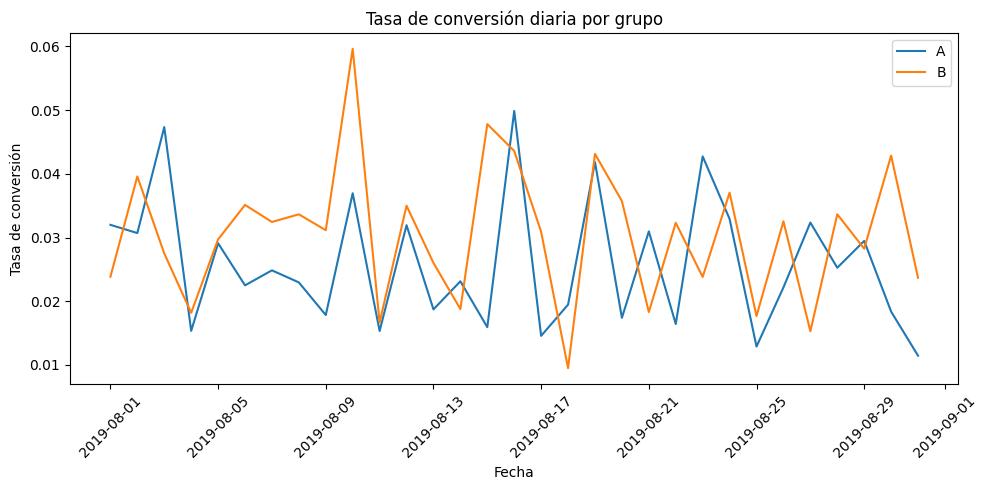

In [ ]:
# Hacemos el gráfico:
# DataFrame con tasa de conversión diaria por día, grupo A
conversion_a = daily_orders_merged[daily_orders_merged['group']=='A'][['date','conversion']]

# DataFrame con ingresos acumulados por día, grupo B
conversion_b = daily_orders_merged[daily_orders_merged['group']=='B'][['date','conversion']]

# Trazar el gráfico de ingresos del grupo A
plt.figure(figsize=(10,5))
plt.plot(conversion_a['date'], conversion_a['conversion'], label='A')

# Trazar el gráfico de ingresos del grupo B
plt.plot(conversion_b['date'], conversion_b['conversion'], label='B')
plt.title('Tasa de conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Vemos una gran cantidad de picos y fluctuaciones en ambos grupos. En los primeros días de la prueba, ambos grupos seguían patrones similares, pues cuando uno subía, el otro también. Sin embargo, a partir del 8/18, ambos grupos seguían caminos totalmente opuestos, ya que cuando uno bajaba, el otro subía y viceversa. Es complicado llegar a una conclusión con este gráfico, por lo que habría que esperar a hacer la prueba de significancia estadística para tomar una decisión. 

### 3.5 Gráfico de dispersión del número de pedidos por usuario

In [ ]:
orders_by_users = orders_clean.groupby('visitorId', as_index=False)['transactionId'].nunique()
orders_by_users.rename(columns={'transactionId':'orders'}, inplace=True)
orders_by_users = orders_by_users.sort_values(by='orders', ascending=False)
orders_by_users.head(10)

,visitorId,orders
908,3967698036,3
55,249864742,3
478,2108163459,3
687,2988190573,3
890,3908431265,3
138,611059232,3
632,2742574263,3
157,678354126,2
323,1404560065,2
452,1985475298,2


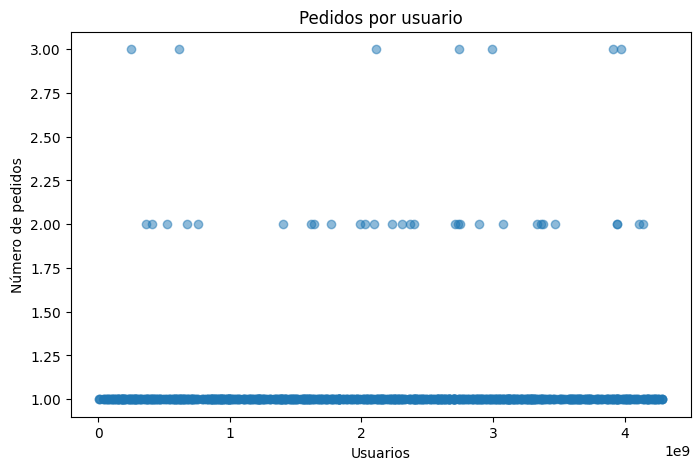

In [ ]:
# Trazamos un gráfico de dispersión
plt.figure(figsize=(8,5))
plt.scatter(orders_by_users['visitorId'], orders_by_users['orders'], alpha=0.5)
plt.title('Pedidos por usuario')
plt.xlabel('Usuarios')
plt.ylabel('Número de pedidos')
plt.show()

Vemos que la gran mayoría de los usuarios han hecho solo un pedido. Varios hacen dos, y muy pocos usuarios hacen 3. 

### 3.6 Cálculo de los percentiles 95 y 99 del número de pedidos por usuario para identificar outliers

In [ ]:
# Calculamos los percentiles 95 y 99 usando el método percentile()
print('Percentiles 95 y 99 del número de pedidos por usuario:', np.percentile(orders_by_users['orders'], [95, 99]))

Percentiles 95 y 99 del número de pedidos por usuario: [1. 2.]


El 95% de los usuarios realizaron 1 pedido. Mientras que el 99% de los usuarios hicieron 2 pedidos o menos. Es decir que solo el 1% realizaron 3 pedidos. Fijaré un umbral de 2 pedidos por usuario y los que realizaron 3 se considerarán anormales, pues solo representan el 1% de los usuarios. 

### 3.7 Gráfico de dispersión de los precios de los pedidos

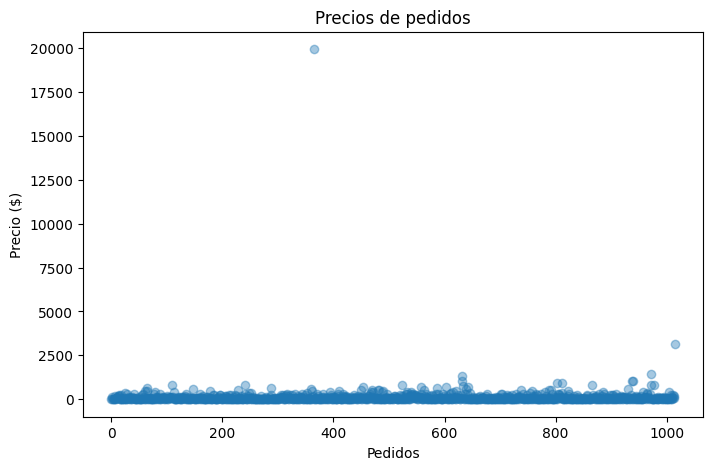

In [ ]:
# Trazamos un gráfico de dispersión
plt.figure(figsize=(8,5))
plt.scatter(range(len(orders_clean)), orders_clean['revenue'], alpha=0.4)
plt.title('Precios de pedidos')
plt.xlabel('Índice')
plt.ylabel('Precio ($)')
plt.show()

La gran mayoría de los usuarios hace pedidos por debajo de 500 dólares. Muy pocos hacen pedidos de más de 1000 dólares. Esto es algo que pasa usualmente en las tiendas, pues hay muy pocos clientes que hacen pedidos muy caros.  

### 3.8 Cálculo de los percentiles 95 y 99 de los precios de los pedidos para identificar outliers

In [ ]:
# Calculamos los percentiles 95 y 99 usando el método percentile()
print('Percentiles 95 y 99 de los precios de pedidos:', np.percentile(orders_clean['revenue'], [95, 99]))

Percentiles 95 y 99 de los precios de pedidos: [414.275 830.3  ]


Por un lado, el 95% de los pedidos son de 414.275 dólares o menos. Por otro lado, el 99% de los pedidos fueron de 830.3 dólares o menos. Al igual que con el tamaño de compra, me quedaré con el percentil 99, es decir, que los pedidos de más de 830.3 se considerarán anormales. 

### 3.9 Significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto

In [ ]:
# Calculamos las conversión total por grupo:
conversion_stats = []

for group in ['A', 'B']:
    total_visitors = visits[visits['group'] == group]['visits'].sum()
    
    total_orders = orders_clean[orders_clean['group'] == group]['transactionId'].nunique()
    
    conversion_rate = total_orders / total_visitors
    
    conversion_stats.append({
        'group': group,
        'visitors': total_visitors,
        'orders': total_orders,
        'conversion_rate': conversion_rate
    })

conversion_df = pd.DataFrame(conversion_stats)
print(conversion_df)

  group  visitors  orders  conversion_rate
0     A     18736     468         0.024979
1     B     18916     548         0.028970


In [ ]:
# Datos para la prueba

visitors_a = conversion_df[conversion_df['group'] == 'A']['visitors'].iloc[0]
orders_a = conversion_df[conversion_df['group'] == 'A']['orders'].iloc[0]
visitors_b = conversion_df[conversion_df['group'] == 'B']['visitors'].iloc[0]
orders_b = conversion_df[conversion_df['group'] == 'B']['orders'].iloc[0]


# Test de proporciones
z_stat, p_value = proportions_ztest(
    [orders_a, orders_b], 
    [visitors_a, visitors_b]
)


print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")
if (p_value < alpha):
    print("Hipótesis nula rechazada: existen diferencias significativas en la conversión entre los grupos")
else:
    print("No se pudo rechazar la hipótesis nula: no podemos sacar conclusiones sobre la diferencia")

Z-statistic: -2.3899344431697442
P-value: 0.01685138043470311
Hipótesis nula rechazada: existen diferencias significativas en la conversión entre los grupos


Los resultados de la prueba Z indican que el grupo B tiene una tasa de conversión mayor que el grupo A, y dado que el p-value fue de 0.016 (menor que el alpha de 0.05), la diferencia sí es estadísticamente significativa. 

### 3.10 Significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto

In [ ]:
# Filtramos los datos para cada grupo:
a_revenue = orders_clean[orders_clean['group']=='A']['revenue']
b_revenue = orders_clean[orders_clean['group']=='B']['revenue']

# Realizamos la prueba Mann Whitney ya que cuando se trata de tamaño de compra, no hay una distribución normal:
alpha = .05

results = st.mannwhitneyu(a_revenue, b_revenue)

print('p-value: ', results.pvalue)

if (results.pvalue < alpha):
    print("Hipótesis nula rechazada: existen diferencias significativas en el tamaño promedio de pedido entre los grupos")
else:
    print("No se pudo rechazar la hipótesis nula: no podemos sacar conclusiones sobre la diferencia")

p-value:  0.8622329690015668
No se pudo rechazar la hipótesis nula: no podemos sacar conclusiones sobre la diferencia


Los resultados de la prueba Mann Whitney nos dicen que no se puede rechazar la hipótesis nula, pues no hay diferencias significativas en el tamaño promedio de compra de los grupos. Esto indica que el cambio en la plataforma no aumentó el tamaño promedio de compra de forma significativa. 

### 3.11 Significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados

In [ ]:
# Extraemos los usuarios anormales, es decir, quienes hicieron más de 2 pedidos y quienes gastaron más de $830.3 en un pedido:
abnormal_orders = orders_by_users[orders_by_users['orders'] > 2] ['visitorId']
abnormal_revenue = orders_clean[orders_clean['revenue'] > 830.3] ['visitorId']
abnormal_users = pd.concat([abnormal_orders, abnormal_revenue])
print(abnormal_users)

908     3967698036
55       249864742
478     2108163459
687     2988190573
890     3908431265
138      611059232
632     2742574263
425     1920142716
743     4133034833
744      888512513
940     4003628586
949      887908475
1099     148427295
1103    1164614297
1136    1307669133
1196    2108080724
Name: visitorId, dtype: int64


In [ ]:
# Creamos el data frame filtrado:
filtered_orders = orders_clean[~orders_clean['visitorId'].isin(abnormal_users)]

In [ ]:
# Calculamos las conversión total por grupo con los datos filtrados:
conversion_stats_f = []

for group in ['A', 'B']:
    total_visitors = visits[visits['group'] == group]['visits'].sum()
    
    total_orders = filtered_orders[filtered_orders['group'] == group]['transactionId'].nunique()
    
    conversion_rate = total_orders / total_visitors
    
    conversion_stats_f.append({
        'group': group,
        'visitors': total_visitors,
        'orders': total_orders,
        'conversion_rate': conversion_rate
    })

conversion_df_f = pd.DataFrame(conversion_stats_f)
print(conversion_df_f)

  group  visitors  orders  conversion_rate
0     A     18736     448         0.023911
1     B     18916     538         0.028442


In [ ]:
# Datos para la prueba
visitors_filtered_a = conversion_df_f[conversion_df_f['group'] == 'A']['visitors'].iloc[0]
orders_filtered_a = conversion_df_f[conversion_df_f['group'] == 'A']['orders'].iloc[0]
visitors_filtered_b = conversion_df_f[conversion_df_f['group'] == 'B']['visitors'].iloc[0]
orders_filtered_b = conversion_df_f[conversion_df_f['group'] == 'B']['orders'].iloc[0]

# Test de proporciones
z_stat, p_value = proportions_ztest(
    [orders_filtered_a, orders_filtered_b], 
    [visitors_filtered_a, visitors_filtered_b]
)

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")
if (p_value < alpha):
    print("Hipótesis nula rechazada: existen diferencias significativas en la conversión entre los grupos")
else:
    print("No se pudo rechazar la hipótesis nula: no podemos sacar conclusiones sobre la diferencia")

Z-statistic: -2.7523779403956374
P-value: 0.005916419709985331
Hipótesis nula rechazada: existen diferencias significativas en la conversión entre los grupos


Los resultados de esta prueba con los datos filtrados siguen indicando que hay una diferencia significativa entre la tasa de conversión de ambos grupos. Tanto el z-statistic como el p-value disminuyeron, lo que nos hace tener más confianza de que esta diferencia es real. 

### 3.12 Significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados


In [ ]:
a_revenue_filtered = filtered_orders[filtered_orders['group']=='A']['revenue']
b_revenue_filtered = filtered_orders[filtered_orders['group']=='B']['revenue']

alpha = .05

results_f = st.mannwhitneyu(a_revenue_filtered, b_revenue_filtered)

print('p-value: ', results_f.pvalue)


if (results_f.pvalue < alpha):
    print("Hipótesis nula rechazada: existen diferencias significativas entre el tamaño promedio de pedido entre los grupos")
else:
    print("No se pudo rechazar la hipótesis nula: no podemos sacar conclusiones sobre la diferencia")


p-value:  0.8220253140355853
No se pudo rechazar la hipótesis nula: no podemos sacar conclusiones sobre la diferencia


Al igual que con la prueba con los datos sin filtrar, los resultados con los datos filtrados dicen que no podemos rechazar la hipótesis nula, pues no se puede concluir que haya una diferencia en el tamaño promedio de compra. Incluso el p-value aumentó, lo que nos acerca más a la hipótesis nula.  

## Parte 4. Conclusiones

Por un lado, la prueba Z para determinar la significancia estadística de la diferencia de la conversión entre los grupos, tanto con los datos en bruto como con los datos filtrados, reveló que sí existía una diferencia significativa y que el grupo B tenía una mejor tasa de conversión que el A. Por otro lado, la prueba Mann-Whitney, con los datos sin procesar y los filtrados, determinó que no había una diferencia significativa en el tamaño promedio de compra. 

Esto indica que en el grupo B se convirtieron más usuarios en clientes en comparación con los del grupo A. Sin embargo, estos clientes no hicieron pedidos grandes, por lo que el tamaño promedio de compra no aumentó. 

En mi opinión, la prueba debería pararse ya que el grupo B fue el líder respecto a la tasa de conversión. Aunque el tamaño promedio no mejoró, de acuerdo al gráfico de ingresos acumulados por grupo (2.1) se muestra que estos fueron mucho mayores en los últimos días para el grupo B que para el A, lo cual es una evidencia más de que el cambio en la plataforma sí hizo una diferencia positiva. 